In [328]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from dataclasses import dataclass 
import math  

In [329]:
class MultiHeadAttention(nn.Module):
    def __init__(self, model_dim, num_heads, device):
        super().__init__()
        self.model_dim = model_dim
        self.head_dim = model_dim // num_heads
        self.num_heads = num_heads
        self.device = device

        self.q_proj = nn.Linear(self.model_dim, self.model_dim, bias=False)
        self.k_proj = nn.Linear(self.model_dim, self.model_dim, bias=False)
        self.v_proj = nn.Linear(self.model_dim, self.model_dim, bias=False)

        self.o_proj = nn.Linear(self.model_dim, self.model_dim, bias=False)

    def forward(self, x, causal=True):
        B, T, D = x.shape
        q = self.q_proj(x)
        k = self.k_proj(x)
        v = self.v_proj(x)

        q = q.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)

        score = torch.matmul(q, k.transpose(-2, -1)) #B, H, T, T
        score = score/math.sqrt(self.head_dim)

        if causal:
            tril = torch.tril(torch.ones(T, T)).to(self.device)
            score = score.masked_fill(tril==0, float('-inf'))
            
        attn_score = F.softmax(score, dim=-1) #B, H, T, T
        attention = torch.matmul(attn_score, v) #B, H, T, D_h
        attention = attention.transpose(1, 2).contiguous().view(B, T, D) #B, T, D

        return self.o_proj(attention) #B, T, D

class LayerNormalization(nn.Module):
    def __init__(self, model_dim):
        super().__init__()
        self.model_dim = model_dim
        self.gamma = nn.Parameter(torch.ones(self.model_dim))
        self.beta = nn.Parameter(torch.zeros(self.model_dim))
        self.eps = 1e-5

    def forward(self, x):
        B, T, D = x.shape
        x_centered = x - torch.mean(x, dim=-1, keepdim=True)
        x_var = torch.mean(x_centered**2, dim=-1, keepdim=True)
        output = x_centered/torch.sqrt(x_var + self.eps)
        return self.gamma * output + self.beta 

In [ ]:
class TransformerBlock(nn.Module):
    def __init__(self, model_dim, num_heads, device) :
        super().__init__()

        self.MHSA = MultiHeadAttention(model_dim, num_heads, device)
        self.layernorm1 = LayerNormalization(model_dim)
        self.layernorm2 = LayerNormalization(model_dim)

        self.FFN = nn.Sequential(   
                        nn.Linear(model_dim, 4*model_dim, bias=False),
                        nn.GELU(),
                        nn.Linear(4*model_dim, model_dim, bias=False)
                    )
    def forward(self, x):
        x1 = x + self.MHSA(self.layernorm1(x))
        x2 = x1 + self.FFN(self.layernorm2(x1))
        return x2

In [331]:
class GPT(nn.Module):
    def __init__(self, cfg):
        super().__init__()

        self.model_dim = cfg.model_dim
        self.num_heads = cfg.num_heads
        self.num_blocks = cfg.num_blocks
        self.vocab_size = cfg.vocab_size
        self.max_seq_len = cfg.max_seq_length
        self.device = cfg.device

        #transformer blocks 
        self.num_blocks = self.num_blocks
        self.blocks = nn.ModuleList([TransformerBlock(self.model_dim, self.num_heads, self.device) for _ in range(self.num_blocks)])
        self.logit_proj = nn.Linear(self.model_dim, cfg.vocab_size, bias=False)

        #token and position embeddings
        self.token_embeddings = nn.Embedding(self.vocab_size, self.model_dim)
        self.pos_emb = nn.Embedding(self.max_seq_len, self.model_dim)


    def forward(self, x, targets):
        B, T = x.shape
        x1 = self.token_embeddings(x) #B, T -> #B, T, D
        x = x1 + self.pos_emb(torch.arange(T, device=self.device))  #B, T, D + (T, D)->B, T, D

        for i in range(self.num_blocks):
            x = self.blocks[i](x)
        
        logits = self.logit_proj(x) #B, T, V

        B, T1, V = logits.shape
        logits = logits.view(B*T1, V)
        targets = targets.reshape(B*T1)

        loss = F.cross_entropy(logits, targets)

        return logits, loss

In [332]:
class Tokenizer:
    def __init__(self):
        self.itos = {}
        self.stoi = {}
        self.vocab_size = 0
    
    def tokenize(self, data):
        char_list = sorted(list(set(data)))
        self.itos = {i:c for i, c in enumerate(char_list)}
        self.stoi = {c:i for i, c in enumerate(char_list)}
        self.vocab_size = len(char_list)
        

    def encode(self, input_s):
        return [self.stoi[c] for c in input_s]
    

    def decode(self, input_tokens):
        return "".join([self.itos[i] for i in input_tokens])   

In [333]:
class TextDataset(Dataset):
    def __init__(self, char_dataset, block_size):
        super().__init__()
        self.data = char_dataset
        self.block_size = block_size

    def __len__(self):
        return len(self.data)-self.block_size

    def __getitem__(self, idx):
        batch_data = self.data[idx:idx+self.block_size] 
        targets =    self.data[idx+1: idx+self.block_size+1] 
        return batch_data, targets    

In [ ]:
from typing import Tuple 

@dataclass
class ConfigParameters:
    vocab_size: int
    device: str
    max_seq_length: int=32
    model_dim: int=64
    num_heads: int=4
    block_size: int=32
    batch_size: int=4
    num_blocks: int=2
   

@dataclass
class OptimParameter:
    lr: float=3e-4
    betas: Tuple=(0.9, 0.95)
    eps: float=1e-8

In [ ]:
torch.manual_seed(700)
fp = open("./data/tinyshakespeare/input.txt")
char_data = fp.read()
len(char_data)

1115394

In [367]:
tokenizer = Tokenizer()
tokenizer.tokenize(char_data)
encoded_data = tokenizer.encode(char_data)

dataset_tensor = torch.tensor(encoded_data, dtype=torch.long)
dataset_tensor.shape

split = 0.9

train_size = int(split*len(dataset_tensor))
train_set = dataset_tensor[:train_size]
val_set = dataset_tensor[train_size:]

In [370]:
device = torch.device("mps")
cfg = ConfigParameters(vocab_size=tokenizer.vocab_size, device=device)
opt_cfg = OptimParameter()
model = GPT(cfg)

optimizer = torch.optim.AdamW(model.parameters(), opt_cfg.lr, betas=opt_cfg.betas, eps=opt_cfg.eps)

In [371]:
train_dataset = TextDataset(train_set, cfg.block_size)
val_dataset = TextDataset(val_set, cfg.block_size)
train_loader = DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=cfg.batch_size)
len(train_loader), len(val_loader)

(250962, 27883)

In [ ]:
model = model.to(device)
model.train()

step = 0
max_steps = 200000
train_loss = []

while step < max_steps:
    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)

        logits, loss = model(x, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss.append(loss.item())
        step += 1
       
        if step >= max_steps:
            break

5000 2.2677528858184814
10000 2.0534777641296387
15000 1.923912525177002
20000 1.9725701808929443
25000 2.0065207481384277
30000 2.206727981567383
35000 1.8027427196502686
40000 1.9843618869781494
45000 1.8249905109405518
50000 1.4630169868469238
55000 2.395669460296631
60000 1.894517421722412
65000 1.7674928903579712
70000 2.5310864448547363
75000 1.5417439937591553
80000 1.946336269378662
85000 1.6852587461471558
90000 1.72740638256073
95000 1.8720729351043701
100000 1.6300456523895264
105000 1.6261844635009766
110000 1.4256497621536255
115000 2.121875762939453
120000 1.7969598770141602
125000 1.4064199924468994
130000 1.5779979228973389
135000 1.7049158811569214
140000 1.6918184757232666
145000 1.5739023685455322
150000 1.8493525981903076
155000 1.874809741973877
160000 1.7789180278778076
165000 1.7021586894989014
170000 2.052614212036133
175000 1.7663581371307373
180000 1.9313172101974487
185000 1.8409656286239624
190000 2.352003335952759
195000 2.203369379043579
200000 1.927330493

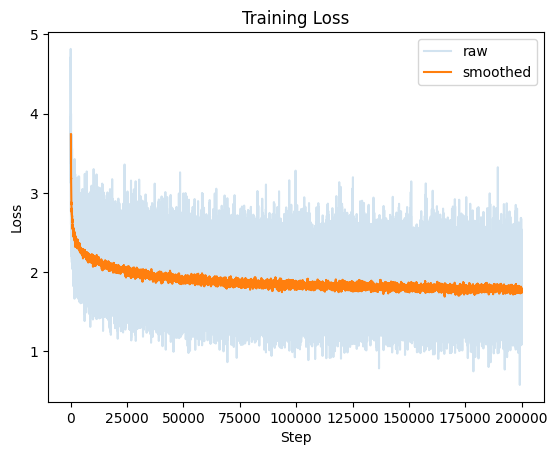

In [373]:
window = 100
smoothed = [
    sum(train_loss[i:i+window]) / window
    for i in range(len(train_loss) - window + 1)
]

import matplotlib.pyplot as plt
plt.plot(train_loss, alpha=0.2, label="raw")
plt.plot(range(window - 1, len(train_loss)), smoothed, label="smoothed")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.legend()
plt.show()